## Simple linear regreation Model

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [51]:
df = pd.read_csv("height-weight.csv")

In [52]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


step1 check the independent and dependent variable

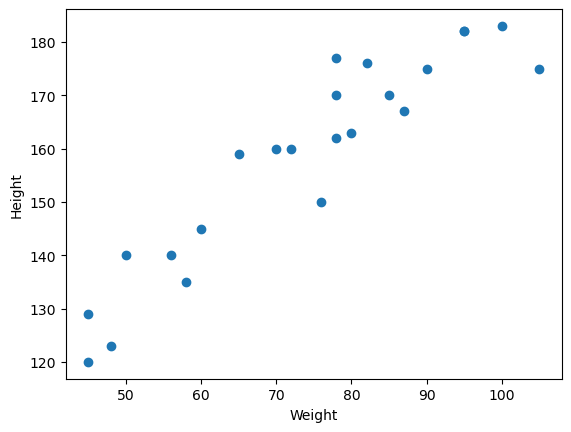

In [53]:
## scatter plot
plt.scatter(df['Weight'] , df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")
plt.show()

In [54]:
# check corelation
df.corr()
# height and weight is highly corelated

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


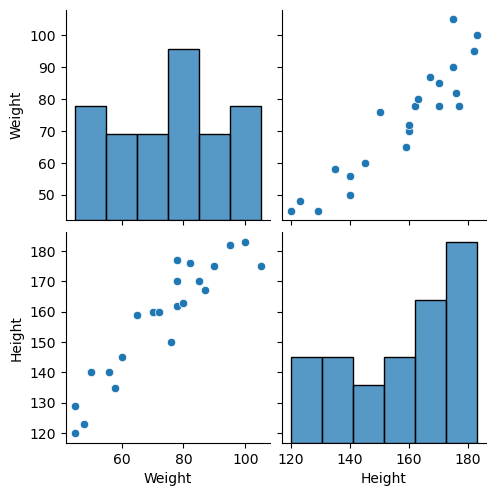

In [55]:
import seaborn as sns
sns.pairplot(df)

In [56]:
# that a example
# not use this type of the 1D array or a series because that give the problem in the traning data set

x_series = df['Weight']
np.array(x_series).shape

(23,)

In [57]:
# Independent and dependent feature
x= df[['Weight']] ### Independent feature allways a data frame or a 2D array
y=df['Height'] #dependent variable allow in series or dataframe / 1D or 2D both
x.head()

,Weight
0,45
1,58
2,48
3,60
4,70


In [58]:
# Train Test Split data
from sklearn.model_selection import train_test_split 

x_train , x_test, y_train, y_test=train_test_split(x,y,test_size=0.25 ,random_state=42)
# random_state use for pick random test and train data

In [59]:
# print(df.shape)
x_test.shape

(6, 1)

In [60]:
# # Standardization in ML
# in standardization we use the zScoure for convert the data set in mean = 0 and standard deviation = 1
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Hum training data par fit_transform() isliye use karte hain kyunki pehle model ko data 
# ka mean aur standard deviation seekhna hota hai, phir usi data ko scale karna hota hai.

# Aur test data par sirf transform() isliye use karte hain taaki training data se nikle 
# hue mean aur standard deviation se hi test data scale ho — warna data leakage ho jaata hai.
# z=(x−μ​)/σ

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [61]:
## Apply the simple linear regreation
from sklearn.linear_model import LinearRegression
regression = LinearRegression(n_jobs=-1)
regression.fit(x_train ,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [62]:
regression.coef_   # give the slope of the best fit line

# y = mx +c 
print("Coefficient or slope" , regression.coef_) # m
# your move one unit in x so the 17.29 unit move in y 

print("Intercept of Best fit line" , regression.intercept_) # c

Coefficient or slope [17.2982057]
Intercept of Best fit line 156.47058823529412


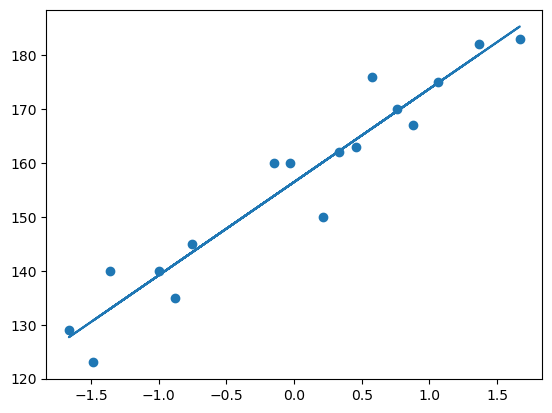

In [63]:
plt.scatter(x_train , y_train)  # simple plot the point
plt.plot(x_train , regression.predict(x_train)) #draw the best fit line

## prediction of test data
1. predicted height output = intercept + coef_(Weights)
2. y_pred_test = 156.470 + 17.29(x_test)

In [64]:
# predictio for test data
y_pred = regression.predict(x_test)
y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

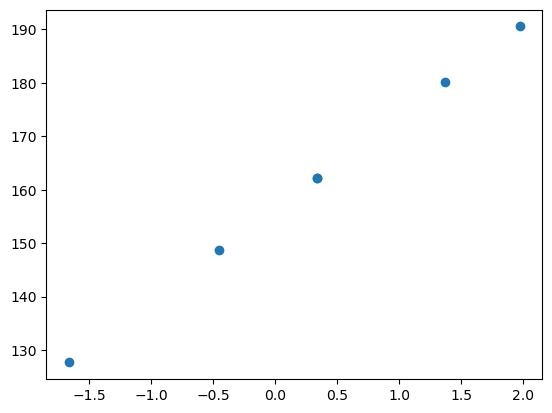

In [65]:
plt.scatter(x_test , y_pred)

In [66]:
# # preformance metrics
from sklearn.metrics import mean_absolute_error , mean_squared_error

mse = mean_squared_error(y_test ,y_pred )
mae = mean_absolute_error(y_test , y_pred)
rmse = np.sqrt(mse)

print(mse)
print(mae)
print(rmse)

114.84069295228699
9.665125886795005
10.716374991212605


## R square 
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [67]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

0.7360826717981276


**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [68]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

0.6701033397476595

In [69]:
## OLS Linear Regression
import statsmodels.api as sm
model=sm.OLS(y_train,x_train).fit()
prediction=model.predict(x_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [70]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sun, 01 Feb 2026   Prob (F-statistic):                       0.664
Time:                        00:17:46   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [71]:
## Prediction For new data
regression.predict(scaler.transform([[55]]))

c:\Users\YASH JAIN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([138.16272159])